[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part3-causal-inference/sec3.3_quasi_experiments.ipynb)

# Estimation code for §3.3 "Quasi Experiments"

The chapter explains three quasi-experimental designs conceptually. This notebook
shows how to *estimate* each one in Python, on small synthetic datasets where we
plant a known effect and check that the estimator recovers it:

- **Difference-in-Differences (DiD)** — the by-hand table, the same estimate from a
  regression (treatment, post, and their interaction, with a clustered standard error),
  and a pre-trend / event-study check of the parallel-trends assumption.
- **Regression Discontinuity (RDD)** — a local linear regression around a cutoff.
- **Synthetic Control** — convex donor weights fit on the pre-period.

Everything runs on `statsmodels` + `scipy`, which ship with the book environment —
no specialized causal-inference library required. The figures in the chapter itself
are produced by the separate `sec3.3_quasi_experiment_figures.ipynb` notebook; this
one is about estimation, so its plots are inline only.

### Setup

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.optimize import minimize
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Difference-in-Differences

### 1a. The estimate by hand

DiD is two subtractions: how much the treatment group changed, minus how much the
control group changed over the same window. The control change is our estimate of
what the treatment group *would* have done anyway (seasonality, inflation, shared
trends), so subtracting it leaves the incremental effect. These are the chapter's
display-pilot numbers.

In [2]:
did = pd.DataFrame({
    "group":  ["Pilot stores", "Comparison stores"],
    "before": [42, 40],   # category sales per store, $k
    "after":  [48, 43],
})
did["change"] = did["after"] - did["before"]
did_estimate = did.loc[0, "change"] - did.loc[1, "change"]

print(did)
print(f"\nDiD estimate: ${did_estimate:.0f}k")   # DiD estimate: $3k

               group  before  after  change
0       Pilot stores      42     48       6
1  Comparison stores      40     43       3

DiD estimate: $3k


### 1b. The same estimate as a regression

The hand calculation gives a point estimate but no standard error, and it doesn't
scale past two groups and two periods. The regression form does both. We build a
store × period panel — 50 pilot stores, 50 comparison stores, 8 periods, with the
in-store display switching on after period 4 — and plant a **true effect of +3**.

The model is `category_sales ~ treated + post + treated:post`. The `treated:post`
interaction *is* the DiD estimate: `treated` absorbs fixed differences between the
groups, `post` absorbs the common time shift, and the interaction is what's left for
the treated group in the post period. We cluster the standard error by store, because
repeated observations of the same store are not independent.

In [3]:
rng = np.random.default_rng(42)

TRUE_EFFECT = 3.0
rows = []
for group in ["comparison", "pilot"]:
    treated = int(group == "pilot")
    for store in range(50):
        store_base = 40 + 2 * treated + rng.normal(0, 1.5)   # treated stores run a bit higher
        for period in range(1, 9):
            post = int(period >= 5)
            category_sales = (
                store_base
                + 0.8 * period                       # common upward trend
                + TRUE_EFFECT * treated * post        # the effect we want to recover
                + rng.normal(0, 0.5)
            )
            rows.append({
                "store_id": f"{group}_{store}",
                "period": period,
                "treated": treated,
                "post": post,
                "category_sales": category_sales,
            })

df = pd.DataFrame(rows)

model = smf.ols("category_sales ~ treated + post + treated:post", data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["store_id"]}
)

did_coef = model.params["treated:post"]
did_se = model.bse["treated:post"]
print(f"DiD estimate (treated:post): {did_coef:.2f}  (SE {did_se:.2f}, true effect {TRUE_EFFECT})")

DiD estimate (treated:post): 3.10  (SE 0.07, true effect 3.0)


The interaction coefficient lands within a standard error of the planted +3 — the
regression recovers the effect we built in, and now reports its uncertainty.

### 1c. Checking parallel trends (event study)

DiD is only credible if the two groups were on parallel paths *before* the program.
We can test this by interacting the treatment indicator with each period (period 1 is
the omitted baseline) and inspecting the coefficients. The
pre-period interactions should be statistically indistinguishable from zero; the
post-period ones should pick up the effect. This is the regression version of "do the
lines look parallel before the intervention?"

In [4]:
event = smf.ols(
    "category_sales ~ treated + C(period) + treated:C(period)",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["store_id"]})

event_terms = event.params.filter(like="treated:C(period)")
event_se = event.bse.filter(like="treated:C(period)")
event_table = pd.DataFrame({"coef": event_terms, "se": event_se})
event_table.index = event_table.index.str.extract(r"\[T\.(\d+)\]")[0].astype(int).values
event_table.index.name = "period"
print(event_table.round(2))
print("\nPre-period interactions (periods 2-4) hover around 0; "
      "post-period interactions (5-8) sit near the +3 effect.")

        coef    se
period            
2       0.03  0.14
3      -0.08  0.16
4       0.01  0.13
5       2.94  0.12
6       3.22  0.13
7       3.17  0.13
8       3.03  0.13

Pre-period interactions (periods 2-4) hover around 0; post-period interactions (5-8) sit near the +3 effect.


## 2. Regression Discontinuity

Customers with at least $500 in pre-campaign annual spend receive a coupon. Customers
just above and just below the cutoff are otherwise nearly identical, so the jump in
subsequent spend right at the threshold estimates the local effect of the coupon.

We plant a **true jump of $60** and estimate it with a *local linear regression*:
keep only customers within a bandwidth of the cutoff, center the running variable at
the cutoff, and fit `y ~ treated + x_centered + treated:x_centered`. Centering makes
the `treated` coefficient the gap *at the cutoff*; the interaction lets the slope
differ on each side. We restrict to a bandwidth because RDD identifies an effect
*local* to the threshold — points far away carry little information about the jump and
can bias a global fit.

In [5]:
rng = np.random.default_rng(7)

CUTOFF = 500
TRUE_JUMP = 60.0
spend = rng.uniform(200, 800, 2000)              # running variable: annual spend
coupon = (spend >= CUTOFF).astype(int)
subsequent = 100 + 0.45 * spend + TRUE_JUMP * coupon + rng.normal(0, 18, spend.size)

rdd = pd.DataFrame({"spend": spend, "coupon": coupon, "subsequent": subsequent})
rdd["x_centered"] = rdd["spend"] - CUTOFF

BANDWIDTH = 100
window = rdd[rdd["x_centered"].abs() <= BANDWIDTH]

rdd_model = smf.ols("subsequent ~ coupon + x_centered + coupon:x_centered", data=window).fit()
rdd_estimate = rdd_model.params["coupon"]
print(f"RDD local estimate at cutoff: ${rdd_estimate:.1f}  "
      f"(SE {rdd_model.bse['coupon']:.1f}, true jump ${TRUE_JUMP:.0f}, "
      f"n={len(window)} within ±${BANDWIDTH})")

RDD local estimate at cutoff: $61.1  (SE 2.7, true jump $60, n=654 within ±$100)


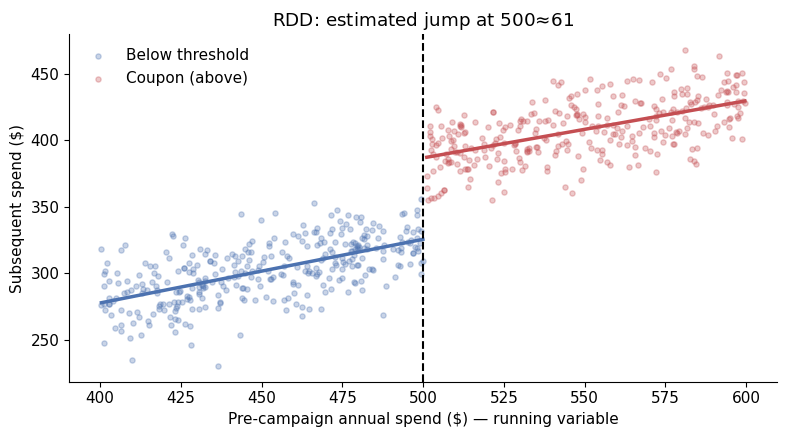

In [6]:
# Visualize the discontinuity with a fitted line on each side of the cutoff.
fig, ax = plt.subplots(figsize=(8, 4.5))
for mask, color, label in [(window["coupon"] == 0, "#4C72B0", "Below threshold"),
                           (window["coupon"] == 1, "#C44E52", "Coupon (above)")]:
    side = window[mask]
    ax.scatter(side["spend"], side["subsequent"], color=color, alpha=0.3, s=14, label=label)
    b, a = np.polyfit(side["spend"], side["subsequent"], 1)
    xs = np.linspace(side["spend"].min(), side["spend"].max(), 50)
    ax.plot(xs, a + b * xs, color=color, lw=2.5)
ax.axvline(CUTOFF, color="black", ls="--", lw=1.5)
ax.set_xlabel("Pre-campaign annual spend ($) — running variable")
ax.set_ylabel("Subsequent spend ($)")
ax.set_title(f"RDD: estimated jump at $500 ≈ ${rdd_estimate:.0f}")
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()

## 3. Synthetic Control

A brand runs an out-of-home campaign in New York but not in other metro markets. To
build the counterfactual — what New York's sales *would* have been without the campaign
— we construct a "synthetic New York" from a weighted blend of untreated donor markets,
choosing the weights so the blend tracks New York's **pre-campaign** trajectory as
closely as possible.

We simulate 5 donor markets and a treated unit that, before the campaign, is a
weighted mix of a few donors plus noise; after the campaign (period 21) we plant a
**true lift of +8 per period**. The weights are found by minimizing pre-period squared
error, subject to the Abadie constraints — non-negative and summing to one — which
keep the synthetic control an interpolation of real units rather than an unconstrained
extrapolation. `scipy.optimize.minimize` with `method="SLSQP"` handles those constraints.

In [7]:
rng = np.random.default_rng(11)

T = 30
INTERVENTION = 21                                  # campaign starts at period 21
TRUE_LIFT = 8.0
periods = np.arange(1, T + 1)
pre = periods < INTERVENTION

# 5 donor markets, each its own level + trend + seasonality + noise
n_donors = 5
donors = np.column_stack([
    rng.uniform(80, 120)
    + rng.uniform(0.8, 1.5) * periods
    + rng.uniform(2, 5) * np.sin(periods / 2 + rng.uniform(0, 3))
    + rng.normal(0, 0.5, T)
    for _ in range(n_donors)
])

# treated unit = mix of a few donors (true weights) + noise, plus the post-period lift
true_w = np.array([0.5, 0.3, 0.2, 0, 0])
treated_unit = donors @ true_w + rng.normal(0, 0.5, T)
treated_unit = treated_unit + np.where(~pre, TRUE_LIFT, 0.0)


def synthetic_weights(donors_pre, treated_pre):
    """Non-negative weights summing to 1 that best match the pre-period (SLSQP)."""
    k = donors_pre.shape[1]

    def loss(w):
        return np.mean((treated_pre - donors_pre @ w) ** 2)

    constraints = ({"type": "eq", "fun": lambda w: w.sum() - 1.0},)
    bounds = [(0.0, 1.0)] * k
    result = minimize(loss, x0=np.full(k, 1.0 / k), method="SLSQP",
                      bounds=bounds, constraints=constraints)
    return result.x


w = synthetic_weights(donors[pre], treated_unit[pre])
synthetic = donors @ w

gap = treated_unit - synthetic
estimated_lift = gap[~pre].mean()
pre_rmse = np.sqrt(np.mean(gap[pre] ** 2))
print(f"Pre-period fit RMSE: {pre_rmse:.2f}  (small = the synthetic tracks the pre-trend)")
print(f"Estimated post-campaign lift: {estimated_lift:.2f} per period  (true lift {TRUE_LIFT})")
print("Donor weights:", np.round(w, 2))

Pre-period fit RMSE: 0.29  (small = the synthetic tracks the pre-trend)
Estimated post-campaign lift: 8.00 per period  (true lift 8.0)
Donor weights: [0.55 0.29 0.16 0.   0.  ]


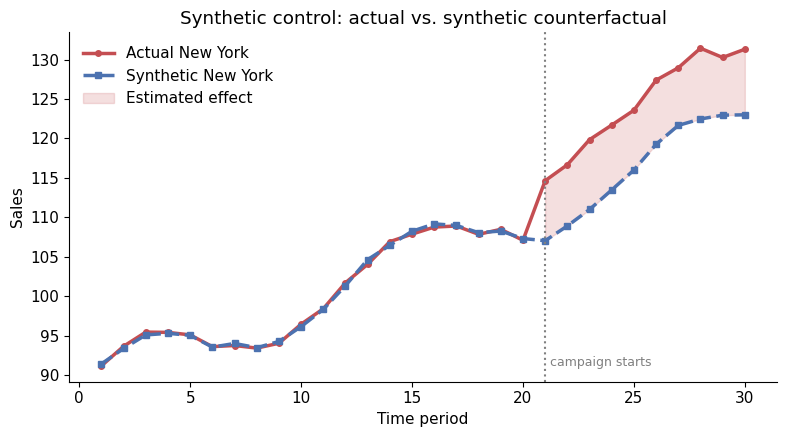

In [8]:
# Actual vs synthetic New York; the post-campaign gap is the estimated effect.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(periods, treated_unit, color="#C44E52", lw=2.5, marker="o", ms=4, label="Actual New York")
ax.plot(periods, synthetic, color="#4C72B0", lw=2.5, ls="--", marker="s", ms=4,
        label="Synthetic New York")
ax.fill_between(periods[~pre], synthetic[~pre], treated_unit[~pre], color="#C44E52", alpha=0.18,
                label="Estimated effect")
ax.axvline(INTERVENTION, color="gray", ls=":", lw=1.5)
ax.annotate("campaign starts", xy=(INTERVENTION, ax.get_ylim()[0] + 2),
            xytext=(INTERVENTION + 0.2, ax.get_ylim()[0] + 2), fontsize=9, color="gray")
ax.set_xlabel("Time period")
ax.set_ylabel("Sales")
ax.set_title("Synthetic control: actual vs. synthetic counterfactual")
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()

The synthetic control tracks New York tightly before the campaign (low pre-period
RMSE), then the actual series pulls away — and the average post gap recovers the lift
we planted. When the pre-period fit is poor, that separation is not trustworthy, which
is why a tight pre-fit is the precondition for reading anything into the post gap.

In [9]:
print("Done — DiD, RDD, and Synthetic Control estimates all recover their planted effects.")

Done — DiD, RDD, and Synthetic Control estimates all recover their planted effects.
